In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('sample_superstore.csv', encoding='latin-1')
print(df)


       Row ID        Order ID  Order Date  Ship Date       Ship Mode  \
0           1  US-2023-103800    1/3/2023   1/7/2023  Standard Class   
1           2  US-2023-112326    1/4/2023   1/8/2023  Standard Class   
2           3  US-2023-112326    1/4/2023   1/8/2023  Standard Class   
3           4  US-2023-112326    1/4/2023   1/8/2023  Standard Class   
4           5  US-2023-141817    1/5/2023  1/12/2023  Standard Class   
...       ...             ...         ...        ...             ...   
10189   10190  US-2026-143259  12/30/2026   1/3/2027  Standard Class   
10190   10191  US-2026-115427  12/30/2026   1/3/2027  Standard Class   
10191   10192  US-2026-156720  12/30/2026   1/3/2027  Standard Class   
10192   10193  US-2026-143259  12/30/2026   1/3/2027  Standard Class   
10193   10194  CA-2026-143500  12/30/2026   1/3/2027  Standard Class   

      Customer ID      Customer Name      Segment Country/Region  \
0        DP-13000      Darren Powers     Consumer  United States   

In [7]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country/Region,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,US-2023-103800,1/3/2023,1/7/2023,Standard Class,DP-13000,Darren Powers,Consumer,United States,Houston,...,77095,Central,OFF-PA-10000174,Office Supplies,Paper,"Message Book, Wirebound, Four 5 1/2"" X 4"" Form...",16.448,2,0.2,5.5512
1,2,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-BI-10004094,Office Supplies,Binders,GBC Standard Plastic Binding Systems Combs,3.540,2,0.8,-5.4870
2,3,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-LA-10003223,Office Supplies,Labels,Avery 508,11.784,3,0.2,4.2717
3,4,US-2023-112326,1/4/2023,1/8/2023,Standard Class,PO-19195,Phillina Ober,Home Office,United States,Naperville,...,60540,Central,OFF-ST-10002743,Office Supplies,Storage,SAFCO Boltless Steel Shelving,272.736,3,0.2,-64.7748
4,5,US-2023-141817,1/5/2023,1/12/2023,Standard Class,MB-18085,Mick Brown,Consumer,United States,Philadelphia,...,19143,East,OFF-AR-10003478,Office Supplies,Art,Avery Hi-Liter EverBold Pen Style Fluorescent ...,19.536,3,0.2,4.8840


In [8]:
print(df.shape)
print(df.columns)
print(df.isnull().sum())

(10194, 21)
Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country/Region', 'City',
       'State/Province', 'Postal Code', 'Region', 'Product ID', 'Category',
       'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount',
       'Profit'],
      dtype='object')
Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country/Region    0
City              0
State/Province    0
Postal Code       0
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Quantity          0
Discount          0
Profit            0
dtype: int64


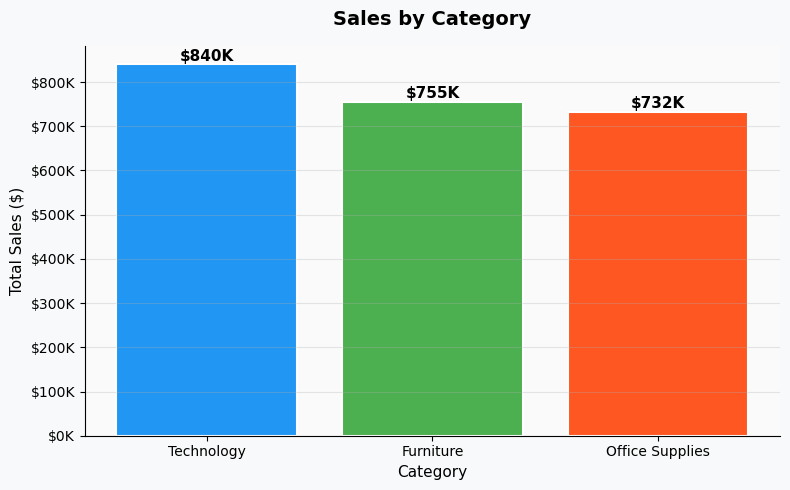

Top Category: Technology
Sales:
 Category
Technology         839893.2790
Furniture          754747.7613
Office Supplies    731893.3140
Name: Sales, dtype: float64


In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Load Data ──────────────────────────────────────────────────────────────
df = pd.read_csv('sample_superstore.csv', encoding='latin-1')

# ── Sales by Category ──────────────────────────────────────────────────────
cat_sales = df.groupby('Category')['Sales'].sum().sort_values(ascending=False)

# ── Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#FAFAFA')

colors = ['#2196F3', '#4CAF50', '#FF5722']

bars = ax.bar(cat_sales.index, cat_sales.values, color=colors, edgecolor='white', linewidth=1.5)

# ── Add value labels on top of each bar ───────────────────────────────────
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2000,
        f'${bar.get_height()/1000:.0f}K',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

# ── Formatting ─────────────────────────────────────────────────────────────
ax.set_title('Sales by Category', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Category', fontsize=11)
ax.set_ylabel('Total Sales ($)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('sales_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

print("Top Category:", cat_sales.idxmax())
print("Sales:\n", cat_sales)

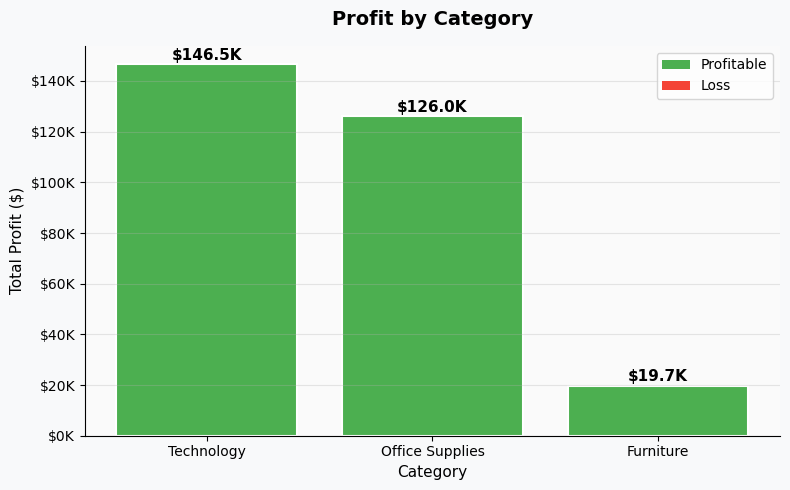

Most Profitable Category: Technology

Profit Breakdown:
 Category
Technology         146543.3756
Office Supplies    126023.4434
Furniture           19729.9956
Name: Profit, dtype: float64


In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Load Data ──────────────────────────────────────────────────────────────
df = pd.read_csv('sample_superstore.csv', encoding='latin-1')

# ── Profit by Category ─────────────────────────────────────────────────────
cat_profit = df.groupby('Category')['Profit'].sum().sort_values(ascending=False)

# ── Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#FAFAFA')

# Green for positive profit, Red for negative profit
colors = ['#4CAF50' if v > 0 else '#F44336' for v in cat_profit.values]

bars = ax.bar(cat_profit.index, cat_profit.values, color=colors, edgecolor='white', linewidth=1.5)

# ── Add value labels on top of each bar ───────────────────────────────────
for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 500,
        f'${bar.get_height()/1000:.1f}K',
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

# ── Formatting ─────────────────────────────────────────────────────────────
ax.set_title('Profit by Category', fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Category', fontsize=11)
ax.set_ylabel('Total Profit ($)', fontsize=11)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.grid(axis='y', alpha=0.3)

# ── Add legend for colors ──────────────────────────────────────────────────
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4CAF50', label='Profitable'),
                   Patch(facecolor='#F44336', label='Loss')]
ax.legend(handles=legend_elements, loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig('profit_by_category.png', dpi=150, bbox_inches='tight')
plt.show()

print("Most Profitable Category:", cat_profit.idxmax())
print("\nProfit Breakdown:\n", cat_profit)

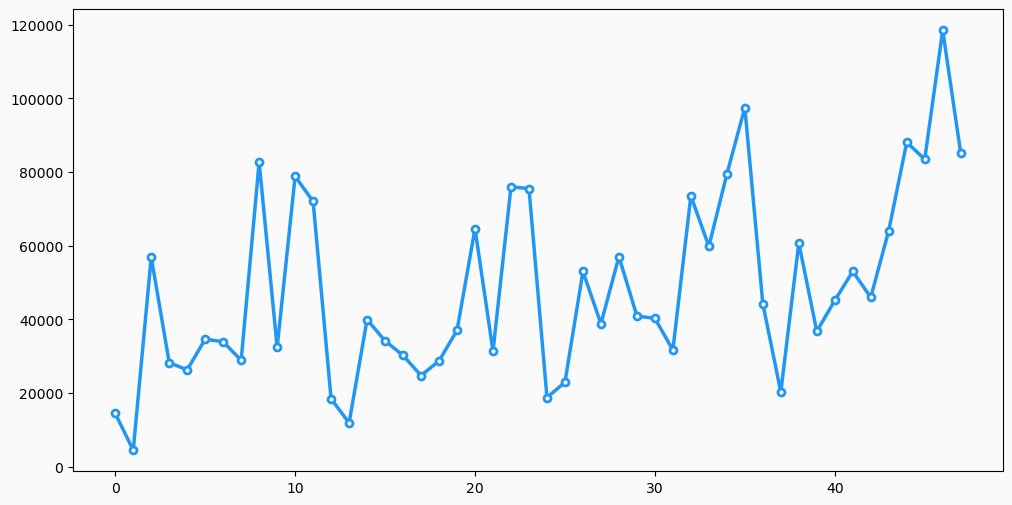

In [15]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

# ── Load Data ──────────────────────────────────────────────────────────────
df = pd.read_csv('sample_superstore.csv', encoding='latin-1')

# ── Convert Order Date to datetime ────────────────────────────────────────
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Month'] = df['Order Date'].dt.to_period('M').astype(str)

# ── Monthly Sales ──────────────────────────────────────────────────────────
monthly_sales = df.groupby('Month')['Sales'].sum().reset_index()
monthly_sales = monthly_sales.sort_values('Month')

# ── Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
fig.patch.set_facecolor('#F8F9FA')
ax.set_facecolor('#FAFAFA')

# ── Line + Shaded Area ─────────────────────────────────────────────────────
x = range(len(monthly_sales))

ax.plot(x, monthly_sales['Sales'],
        color='#2196F3', linewidth=2.5,
        marker='o', markersize=5,
        markerfacecolor='white', markeredgewidth=2)

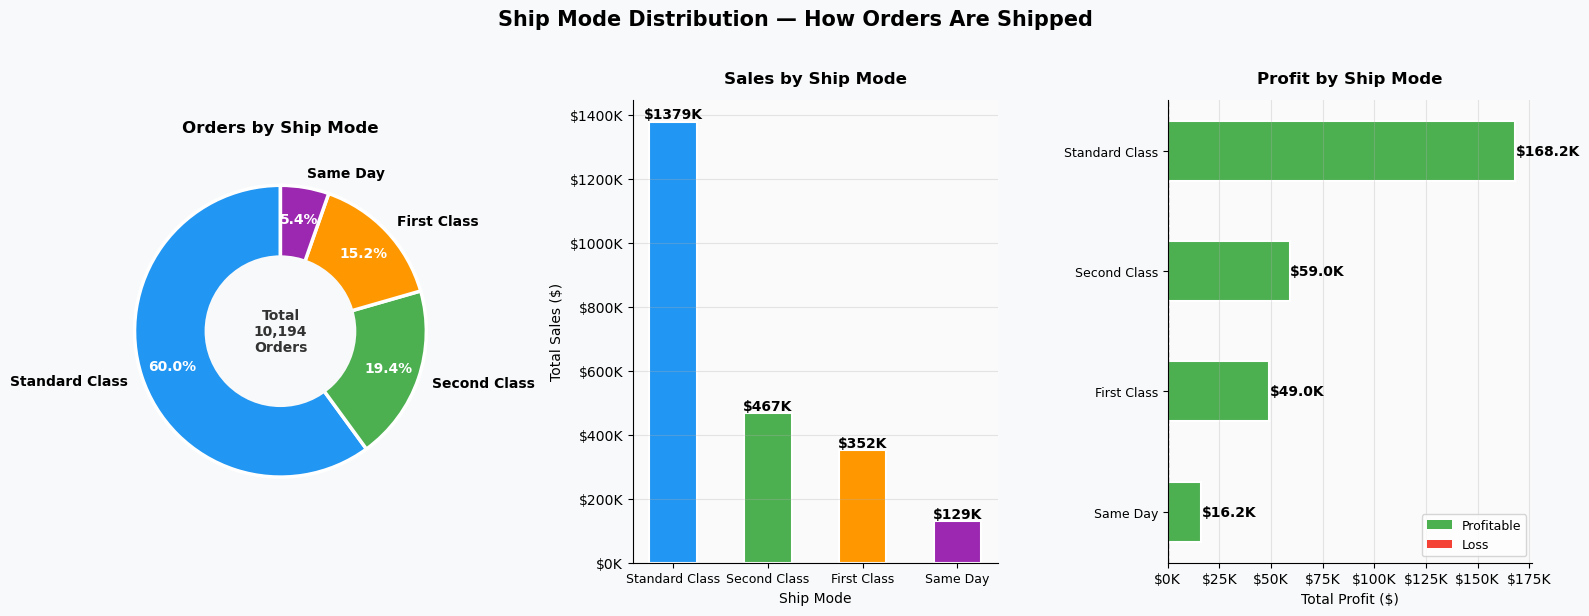

Most Used Ship Mode  : Standard Class → 6,120 orders
Top Sales Ship Mode  : Standard Class → $1378.8K
Top Profit Ship Mode : Standard Class → $168.2K


In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

# ── Load Data ──────────────────────────────────────────────────────────────
df = pd.read_csv('sample_superstore.csv', encoding='latin-1')

# ── Ship Mode Data ─────────────────────────────────────────────────────────
ship_counts  = df['Ship Mode'].value_counts()
ship_sales   = df.groupby('Ship Mode')['Sales'].sum()
ship_profit  = df.groupby('Ship Mode')['Profit'].sum()

# ── Plot: 1 row, 3 charts ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.patch.set_facecolor('#F8F9FA')
fig.suptitle('Ship Mode Distribution — How Orders Are Shipped',
             fontsize=15, fontweight='bold', y=1.02)

COLORS = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0']

# ══════════════════════════════════════════════════
# Chart 1 — Order Count by Ship Mode (Donut)
# ══════════════════════════════════════════════════
ax1 = axes[0]

wedges, texts, autotexts = ax1.pie(
    ship_counts.values,
    labels=ship_counts.index,
    autopct='%1.1f%%',
    colors=COLORS,
    startangle=90,
    pctdistance=0.78,
    wedgeprops=dict(edgecolor='white', linewidth=2.5)
)

for text in texts:
    text.set_fontsize(10)
    text.set_fontweight('bold')

for autotext in autotexts:
    autotext.set_fontsize(10)
    autotext.set_fontweight('bold')
    autotext.set_color('white')

# ── Donut hole with total orders ───────────────────────────────────────────
centre_circle = plt.Circle((0, 0), 0.52, fc='#F8F9FA')
ax1.add_patch(centre_circle)
ax1.text(0, 0, f'Total\n{ship_counts.sum():,}\nOrders',
         ha='center', va='center',
         fontsize=10, fontweight='bold', color='#333333')

ax1.set_title('Orders by Ship Mode', fontsize=12, fontweight='bold', pad=12)

# ══════════════════════════════════════════════════
# Chart 2 — Sales by Ship Mode (Bar Chart)
# ══════════════════════════════════════════════════
ax2 = axes[1]
ax2.set_facecolor('#FAFAFA')

ship_sales_sorted = ship_sales.sort_values(ascending=False)
bars = ax2.bar(ship_sales_sorted.index, ship_sales_sorted.values,
               color=COLORS, edgecolor='white', linewidth=1.5, width=0.5)

# ── Value labels ───────────────────────────────────────────────────────────
for bar in bars:
    ax2.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 2000,
        f'${bar.get_height()/1000:.0f}K',
        ha='center', va='bottom', fontsize=10, fontweight='bold'
    )

ax2.set_title('Sales by Ship Mode', fontsize=12, fontweight='bold', pad=12)
ax2.set_xlabel('Ship Mode', fontsize=10)
ax2.set_ylabel('Total Sales ($)', fontsize=10)
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax2.tick_params(axis='x', labelsize=9)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)
ax2.grid(axis='y', alpha=0.3)

# ══════════════════════════════════════════════════
# Chart 3 — Profit by Ship Mode (Horizontal Bar)
# ══════════════════════════════════════════════════
ax3 = axes[2]
ax3.set_facecolor('#FAFAFA')

ship_profit_sorted = ship_profit.sort_values(ascending=True)
profit_colors = ['#4CAF50' if v > 0 else '#F44336' for v in ship_profit_sorted.values]

hbars = ax3.barh(ship_profit_sorted.index, ship_profit_sorted.values,
                 color=profit_colors, edgecolor='white', linewidth=1.5, height=0.5)

# ── Value labels ───────────────────────────────────────────────────────────
for bar in hbars:
    width = bar.get_width()
    ax3.text(
        width + 300,
        bar.get_y() + bar.get_height() / 2,
        f'${width/1000:.1f}K',
        ha='left', va='center', fontsize=10, fontweight='bold'
    )

# ── Zero line ──────────────────────────────────────────────────────────────
ax3.axvline(0, color='gray', linestyle='--', linewidth=1)

ax3.set_title('Profit by Ship Mode', fontsize=12, fontweight='bold', pad=12)
ax3.set_xlabel('Total Profit ($)', fontsize=10)
ax3.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1000:.0f}K'))
ax3.tick_params(axis='y', labelsize=9)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)
ax3.grid(axis='x', alpha=0.3)

# ── Legend ─────────────────────────────────────────────────────────────────
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4CAF50', label='Profitable'),
                   Patch(facecolor='#F44336', label='Loss')]
ax3.legend(handles=legend_elements, loc='lower right', fontsize=9)

plt.tight_layout()
plt.savefig('ship_mode_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print("Most Used Ship Mode  :", ship_counts.idxmax(),  f"→ {ship_counts.max():,} orders")
print("Top Sales Ship Mode  :", ship_sales.idxmax(),   f"→ ${ship_sales.max()/1000:.1f}K")
print("Top Profit Ship Mode :", ship_profit.idxmax(),  f"→ ${ship_profit.max()/1000:.1f}K")